## Step 1(a): Construction of the Non-Uniform State-Space Grid

We construct a finite state-space grid \( G \subset (0,\infty) \) following the approach of Mijatovic and Pistorius (Section 4). The purpose of this grid is to approximate the continuous state space of the underlying asset by a discrete set of points on which a continuous-time Markov chain will be defined.

The grid is built as the union

$
G = G_1 \cup G_2 \cup G_3,
$

where:

- \( $G_1$ \) concentrates points near the lower barrier \( $l $ \),
- \( $G_2$ \) concentrates points near the current spot \( $S_0$ \),
- \( $G_3$ \) concentrates points near the upper barrier \( $u$ \).

Each subgrid is generated using a hyperbolic sine transformation, which allows clustering of points around a chosen centre while keeping the grid strictly increasing. This ensures higher resolution near the barriers and the spot (where accuracy is most important), and coarser spacing away from these regions.

The parameters:

- `N1, N2, N3` control the number of points in each region,
- `d*_minus, d*_plus` control the local density of points,
- `x_min, x_max` truncate the state space.

The resulting grid contains the lower barrier, spot, and upper barrier exactly, ensuring they are valid Markov states.

In [141]:
import numpy as np

def generate_subgrid(a: float, s: float, b: float, N_i: int, d_minus: float, d_plus: float) -> np.ndarray:
    """
    Subgrid generator (Mijatović–Pistorius style).
    If N_i is odd, it is increased by 1 to make it even.
    """
    if not (a < s < b):
        raise ValueError("Require a < s < b.")
    if N_i < 4:
        raise ValueError("N_i must be >= 4.")
    if N_i % 2 != 0:
        N_i = N_i + 1  # auto-fix odd N_i
    if d_minus <= 0 or d_plus <= 0:
        raise ValueError("d_minus,d_plus must be positive.")

    c1 = np.arcsinh((a - s) / d_minus)
    c2 = np.arcsinh((b - s) / d_plus)

    half = int(N_i / 2)

    
    k = np.arange(1, half + 1)
    x_low = s + d_minus * np.sinh(c1 * (1 - (k - 1) / (half - 1)))

    k = np.arange(1, half + 1)
    x_up = s + d_plus * np.sinh(c2 * (2 * k / N_i))

    x = np.concatenate([x_low, x_up])

    # enforce monotone increasing + exact endpoints
    x = np.maximum.accumulate(x)
    x[0] = a
    x[half - 1] = s
    x[-1] = b
    return x


def build_nonuniform_grid(
    S0: float,
    l: float,
    u: float,
    x_min: float,
    x_max: float,
    N1: int,
    N2: int,
    N3: int,
    d1_minus: float, d1_plus: float,
    d2_minus: float, d2_plus: float,
    d3_minus: float, d3_plus: float,
) -> np.ndarray:
    """
    Build G = G1 ∪ G2 ∪ G3:
      - G1 spans [x_min, l] centred at l
      - G2 spans [(S0+l)/2, (u+S0)/2] centred at S0
      - G3 spans [u, x_max] centred at u

    Ensures l, S0, u lie on the grid (up to floating tolerance).
    """
    if not (0 < x_min < l < u < x_max):
        raise ValueError("Require 0 < x_min < l < u < x_max.")
    if not (l < S0 < u):
        raise ValueError("Require l < S0 < u.")
    if any(v <= 0 for v in [d1_minus,d1_plus,d2_minus,d2_plus,d3_minus,d3_plus]):
        raise ValueError("All density parameters must be positive.")

    a1, s1, b1 = x_min, l, (S0 + l) / 2.0
    a2, s2, b2 = b1, S0, (u + S0) / 2.0
    a3, s3, b3 = b2, u, x_max

    G1 = generate_subgrid(a1, s1, b1, N1, d1_minus, d1_plus)
    G2 = generate_subgrid(a2, s2, b2, N2, d2_minus, d2_plus)
    G3 = generate_subgrid(a3, s3, b3, N3, d3_minus, d3_plus)

    # concatenate, remove duplicates from joins, ensure sorted
    G = np.unique(np.concatenate([G1, G2, G3]))
    G.sort()

    return G

## Visualisation of the Non-Uniform Grid

To illustrate the structure of the constructed state space, we plot the grid points on the real line. Each vertical marker represents a state of the continuous-time Markov chain.

The lower barrier `l`, upper barrier `u`, and initial spot `S0` are highlighted for reference. This visualisation confirms:

- Increased concentration of points near the barriers and spot,
- Wider spacing away from these regions,
- Proper inclusion of the barriers and initial state in the grid.

Such clustering is essential for accurately approximating first-passage behaviour, since barrier options are highly sensitive to the dynamics near the barriers.

In [142]:
import numpy as np
import matplotlib.pyplot as plt

def plot_grid(G, S0=None, l=None, u=None):
    G = np.asarray(G)

    fig, ax = plt.subplots(figsize=(10, 2.8))

    # Put grid markers slightly below 0 so the legend can sit above them
    y_grid = -0.25
    ax.scatter(G, np.full_like(G, y_grid), marker='|', s=220,
               color="royalblue", label="Grid points")

    if S0 is not None:
        ax.axvline(S0, linestyle='--', linewidth=1.5, label='S0', color='seagreen')
    if l is not None:
        ax.axvline(l, linestyle='--', linewidth=1.5, label='Lower barrier', color='tomato')
    if u is not None:
        ax.axvline(u, linestyle='--', linewidth=1.5, label='Upper barrier', color='tomato')

    # Create vertical space above the markers so legend doesn't overlap
    ax.set_ylim(-1.0, 1.0)
    ax.set_yticks([])
    ax.set_xlabel("State space")
    ax.set_title("Non-uniform Markov Chain Grid")
    ax.legend(
        loc="upper left",
        frameon=True,
        fancybox=False,     
        framealpha=1.0,
        edgecolor="black"
    )
    plt.tight_layout()
    plt.show()

Grid size: 76
First/last: 50.0 150.0
Closest to S0: 100.0


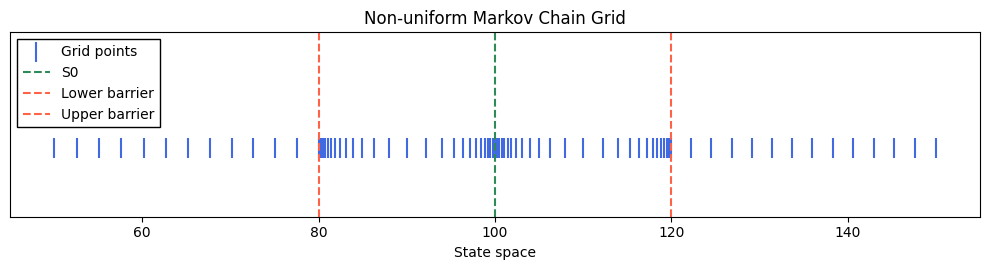

In [143]:
# Example usage (matches the spirit of Figure 2 in the paper)

S0, l, u = 100.0, 80.0, 120.0
G = build_nonuniform_grid(
    S0=S0, l=l, u=u,
    x_min=50.0, x_max=150.0,
    N1=25, N2=25, N3=25,
    d1_minus=100.0, d1_plus=1.0,
    d2_minus=1.0,   d2_plus=1.0,
    d3_minus=1.0,   d3_plus=100.0,
)
print("Grid size:", len(G))
print("First/last:", G[0], G[-1])
print("Closest to S0:", G[np.argmin(np.abs(G - S0))])

plot_grid(G, S0=S0, l=l, u=u)

### Step 1(b): Construction of the Generator Matrix

Following *Continuously Monitored Barrier Options under Markov Processes*, the generator of the Markov chain is

$$
\Lambda = \Lambda_J + \Lambda_D.
$$

- $\Lambda_J$ represents the **jump component**.
- $\Lambda_D$ represents the **diffusion component**.

The function

```python
build_generator(G)
```

returns the full generator by summing these two parts.

---

#### Jump Generator $\Lambda_J$

For each interior grid point $x_i$, relative jump sizes are computed

$$
y = \frac{z}{x_i} - 1, \qquad z \in G.
$$

A partition of the jump space is constructed

$$
\alpha_x(y_i) = \frac{y_i + y_{i+1}}{2}.
$$

The jump intensity between grid points is obtained by integrating the jump density

```python
LambdaJ[i, j] = quad(lambda y: vega(x, y), a, b)[0]
```

The diagonal element is set so that each row sums to zero:

$$
\Lambda_J(x,x) = -\sum_{z\neq x}\Lambda_J(x,z).
$$

---

#### Diffusion Generator $\Lambda_D$

The diffusion component satisfies equations (4.6)–(4.8) of the paper and is assumed to be **tri-diagonal**, meaning transitions only occur to neighbouring grid points $x_{i-1}$ and $x_{i+1}$.

Equation (4.7):

$$
\sum_z \Lambda_D(x,z)(z-x)
=
(r-d)x - \sum_z \Lambda_J(x,z)(z-x).
$$

Equation (4.8):

$$
\sum_z \Lambda_D(x,z)(z-x)^2
=
x^2\left[\sigma(x)^2 + \int_{-1}^{\infty} y^2\nu(x,dy)\right]
-
\sum_z \Lambda_J(x,z)(z-x)^2.
$$

These two equations determine the transition rates to $x_{i-1}$ and $x_{i+1}$.

Finally, equation (4.6) ensures rows sum to zero:

$$
\sum_z \Lambda_D(x,z) = 0.
$$

The full generator matrix used in the Markov chain approximation is therefore

$$
\Lambda = \Lambda_J + \Lambda_D.
$$



In [144]:
import numpy as np
from scipy.integrate import quad

def build_generator(G: np.ndarray, r: float, d: float, sigma:float) -> np.ndarray:

    LambdaJ = build_jump_generator(G)
    LambdaD = build_diag_generator(G, LambdaJ, r, d, sigma)

    return LambdaD + LambdaJ


def vega(x,dy):
    #What do I put here? The paper does not specify. I guess it is the jump density, but I am not sure how to choose it. I will just put a placeholder for now.
    return 0

def build_jump_generator(G: np.ndarray) -> np.ndarray:

    N = len(G)
    LambdaJ = np.zeros((N, N), dtype=float)

    # loop over interior grid points only (exclude boundaries G[0] and G[N-1], which are absorbing states)
    for i in range(1, N-1):

        x = G[i]

        G_x = G/x - 1
        G_x.sort()

        alpha_x = (G_x[:-1] + G_x[1:]) / 2


        #Ask about the end points, the paper says it is a proper subset of (1,inf) but it is not clear how to choose them. I have chosen -1 and inf for now, but this is just a guess.
        alpha = np.zeros(N+1)
        alpha[0] = -1
        alpha[-1] = np.inf
        alpha[1:-1] = alpha_x

        for j in range(N):

            if j == i:
                continue

            a = alpha[j]
            b = alpha[j+1]

            LambdaJ[i, j] = quad(lambda y: vega(x, y), a, b)[0] #Ask about vega, I know it is jump diff

        LambdaJ[i, i] = -np.sum(LambdaJ[i])

    return LambdaJ

def build_diag_generator(G: np.ndarray, LambdaJ: np.ndarray, r: float, d: float, sigma:float) -> np.ndarray:

    N = len(G)
    LambdaD = np.zeros((N, N), dtype=float)

    for i in range(1, N-1):

        x = G[i]
        x_left = G[i-1]
        x_right = G[i+1]

        # Equation (4.7)
        rhs_one = (r - d) * x - np.sum(LambdaJ[i] * (G - x))

        # Equation (4.8)
        jump_integral = quad(lambda y: y**2 * vega(x, y), -1, np.inf)[0] #Ask about vega, I know it is jump diff
        rhs_two = x**2 * (sigma**2 + jump_integral) - np.sum(LambdaJ[i] * (G - x)**2)

        # solve for Lambda_D(x,x_left) and Lambda_D(x,x_right)
        A = np.array([[x_left - x, x_right - x],
                      [(x_left - x)**2, (x_right - x)**2]])

        B = np.array([rhs_one, rhs_two])

        rate_left, rate_right = np.linalg.solve(A, B)

        LambdaD[i, i-1] = rate_left
        LambdaD[i, i+1] = rate_right

        # Equation (4.6)
        LambdaD[i, i] = -(rate_left + rate_right)

    return LambdaD

## Step 2 (Section 3) ##

What should I do with phi and psi? I know phi is the payoff function and psi is also a function. Copilot keeps suggesting a matrix multiplication?

In [145]:
#What do I do for the payoff function? The paper does not specify. I will just put a placeholder for now.
import numpy as np
from scipy.linalg import expm

def transisiton_matrix(A:np.ndarray, dt:float) -> np.ndarray:
    return expm(A * dt)

def phi():
    return

def psi():
    return

#Equation (3.6)
def build_Lambda_tilde_r(Lambda: np.ndarray, G: np.ndarray, lower_barrier: float, upper_barrier: float, r: float) -> np.ndarray:
    
    N = len(G)
    G_hat = np.where((G > lower_barrier) & (G < upper_barrier))[0]

    Lambda_tilde_r = np.zeros((N, N))

    for i in G_hat:
        for j in range(N):
            Lambda_tilde_r[i, j] = Lambda[i, j]   # copy whole row first
        Lambda_tilde_r[i, i] -= r                 # then subtract r on diagonal

    return Lambda_tilde_r


#Equation (3.7)
def build_Lambda_hat(Lambda: np.ndarray, G: np.ndarray, lower_barrier:float, upper_barrier:float) -> np.ndarray:

    G_hat = np.where((G > lower_barrier) & (G < upper_barrier))[0]
    Lambda_hat = Lambda[np.ix_(G_hat, G_hat)]

    return Lambda_hat

#Equation (3.8)
def theorem_3_8_value(Lambda, G, lower_barrier, upper_barrier, r, T, E):

    Lambda_tilde_r = build_Lambda_tilde_r(Lambda, G, lower_barrier, upper_barrier, r)
    phi = np.maximum(E - G, 0.0)           # payoff on the grid
    i0 = np.argmin(np.abs(G - 40.0))
    value_vec = expm(T * Lambda_tilde_r) @ phi

    return {"option_price":value_vec[i0], "option_tree":value_vec}

#Equation (3.9)
def theorem_3_9_value(Lambda_hat, psi, T):
    return expm(T * Lambda_hat) @ psi #What should I do with psi?

In [146]:
#Equation (3.1) Discounted payoff of the European put option
def european_put_value(Lambda, G, E, T, r):

    phi_euro = np.maximum(E - G, 0.0)           # payoff on the grid
    i0 = np.argmin(np.abs(G - 40.0))
    value_vec = np.exp(-r * T) * (expm(T * Lambda) @ phi_euro)

    return {"option_price":value_vec[i0], "option_tree":value_vec}  

#Equation (3.1) Discounted payoff of the European Call option
def european_call_value(Lambda, G, E, T, r):

    phi_euro = np.maximum(G - E, 0.0)           # payoff on the grid
    i0 = np.argmin(np.abs(G - 40.0))
    value_vec = np.exp(-r * T) * (expm(T * Lambda) @ phi_euro)

    return {"option_price":value_vec[i0], "option_tree":value_vec} 

## Euro Compare

Grid size: 88
First/last: 0.1 100.0
Closest to S0: 40.0


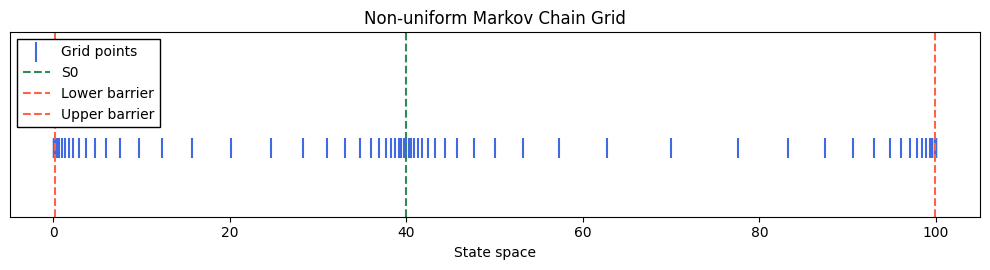

True
1.8466971745404543
1.8466971688521847


In [149]:
S0, E, r, T, option_type, sigma, d = 40, 32, 0.1, 0.5, "put", 0.54202, 0.0
BSE ,Euro_30_bin = 1.8507 , 1.88
l,u = 0.2, 99.9

G = build_nonuniform_grid(
    S0=S0, l=l, u=u,
    x_min=0.1, x_max=100,
    N1=30, N2=30, N3=30,
    d1_minus=20, d1_plus=1.0,
    d2_minus=1.0,   d2_plus=1.0,
    d3_minus=1.0,   d3_plus=20,
)

print("Grid size:", len(G))
print("First/last:", G[0], G[-1])
print("Closest to S0:", G[np.argmin(np.abs(G - S0))])

plot_grid(G, S0=S0, l=l, u=u)

#Generator Building
Lambda = build_generator(G, r, d, sigma)
print(np.all(build_jump_generator(G) == 0))

#Equation (3.1)
result = european_put_value(Lambda, G, E, T, r)
print(result["option_price"])

#Equation (3.8)
result = theorem_3_8_value(Lambda, G, l, u, r, T, E)
print(result["option_price"])